# Coeficientes de Floquet

Vamos a armar un programa que pueda hacer una tabla de inestabilidades para cualquier tipo de potencial $V(\phi)$.

## Física

**$\LARGE{\text{Ecuaciones dinámicas}}$**

Durante recalentamiento tenemos que las ecuaciones de movimiento que rigen el background y las perturbaciones son las siguientes:

$$\ddot{\phi} + 3 \frac{\dot{a}}{a} \dot{\phi} + \frac{dV}{d\phi} = 0$$

$$\delta \ddot{\phi}_k + 3 \frac{\dot{a}}{a} ~ \delta \dot{\phi}_k + \left[ \frac{k^2}{a^2} + \frac{d^2 V}{d\phi^2} \right] \delta \phi_k = 0$$

$$\ddot{\chi}_k + 3 \frac{\dot{a}}{a} \dot{\chi}_k + \left( \frac{k^2}{a^2} + g^2 \phi^2 \right) \chi_k = 0$$

$$\ddot{a} + \frac{a}{3 m_p^2} \left[ \dot{\phi}^2 - V (\phi) \right] = 0$$

Y para hacer un análisis de tipo Floquet necesitamos que el universo no se expanda lo que implica tomar $a = 1 = cte$ y $H = 0$, por tanto tenemos que en ese caso las ecuaciones nos quedan de la siguiente forma:

$$\ddot{\phi} + \frac{dV}{d\phi}= 0$$

$$\delta \ddot{\phi}_k + \left( k^2 + \frac{d^2 V}{d\phi^2} \right) \delta \phi_k = 0$$

$$\ddot{\chi}_k + \left( k^2 + g^2 \phi^2 \right) \chi_k = 0$$

**$\LARGE{\text{Conservación de la energía}}$**

Para hacer un análisis de tipo Floquet necesitamos conocer el período de oscilación del inflatón y para ello usaremos la conservación de la energía, la cual surge de plantear que el universo no se expande:

- A tiempo inicial para reheating tenemos 

$$E = \frac{\dot{\phi}_0^2}{2} + V(\phi_0)$$

- Y para un tiempo arbitrario tenemos 

$$E = \frac{\dot{\phi}^2}{2} + V(\phi)$$

**$\LARGE{\text{Período de oscilación del infaltón}}$**

Despejando de la última ecuación tenemos

$$\dot{\phi} = \sqrt{2 \left[E - V \left( \phi \right) \right]}$$

$$\frac{d\phi}{dt} = \sqrt{2 \left[E - V \left( \phi \right) \right]}$$

$$dt = \frac{d\phi}{\sqrt{2 \left[E - V \left( \phi \right) \right]}}$$

$$\int_0^T dt = 2 \int_{-\phi_{max}}^{\phi_{max}} \frac{d\phi}{\sqrt{2 \left[E - V \left( \phi \right) \right]}}$$

$$T = \frac{4}{\sqrt{2 E}} \int_{0}^{\phi_{max}} \frac{d\phi}{\displaystyle \sqrt{1- \frac{V \left( \phi \right)}{E}}}$$

**$\LARGE{m^2 \phi^2}$**

Veamos cuánto vale para $V(\phi) = m^2 \phi^2$ para verificar que da una constante

$$T = \frac{4}{\sqrt{4 E}} \int_{0}^{\phi_{max}} \frac{d\phi}{\displaystyle \sqrt{1- \frac{m^2 \phi^2}{2E}}}$$

- Definimos $\displaystyle \sin (u) = \frac{m \phi}{\sqrt{2E}}$ y $\displaystyle \cos (u) ~ du = \frac{m}{\sqrt{2E}} ~ d\phi$, tal que la integral nos queda de la siguiente forma

$$T = \frac{2}{m} \int^{-\arcsin \left( \frac{m \phi_{max}}{\sqrt{2E}} \right)}_{0} \frac{\cos u ~ du}{\displaystyle \sqrt{1- \sin^2 u}}$$

$$T = \frac{2}{m} \int^{-\arcsin \left( \frac{m \phi_{max}}{\sqrt{2E}} \right)}_0 \frac{\cos u ~ du}{\displaystyle \cos u}$$

$$T = \frac{2}{m} \int^{-\arcsin \left( \frac{m \phi_{max}}{\sqrt{2E}} \right)}_{0} du$$

$$T = \frac{2}{m} \arcsin \left( \frac{m \phi_{max}}{\sqrt{2E}} \right)$$

$$T = \frac{2}{m} \arcsin \left( \frac{m \phi_{max}}{\sqrt{2E}} \right)$$

Podemos ver que el valor del máximo del campo sale de $E = V(\phi_{max})$ que en el caso de $\displaystyle V(\phi) = \frac{1}{2} m^2 \phi^2$ tenemos $\displaystyle \phi_{max} = \frac{\sqrt{2E}}{m}$ y por tanto

$$T = \frac{2}{m} \arcsin \left( \frac{m \sqrt{2E}}{m \sqrt{2E}} \right)$$

$$T = \frac{2\pi}{m}$$

## Librerías

In [1]:
import os
import numpy as np
from tqdm import tqdm 
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.integrate import quad
from scipy.signal import find_peaks
from scipy.optimize import curve_fit
from scipy.integrate import solve_ivp

mpl.rc('figure', figsize=(12, 6))
mpl.rc('text', usetex = False)
mpl.rc('font', family = 'serif')
mpl.rc('font', size = '14')
mpl.rc('xtick', labelsize=14) 
mpl.rc('ytick', labelsize=14)
mpl.rcParams['mathtext.fontset'] = 'stix'

## $m^2 \phi^2$

Correcciones a tener en cuenta:
- Cuidado que g y q son distintas, se relacionan a partir de $\displaystyle q = \frac{g^2 \tilde{\phi}_0^2}{4}$.
- $\displaystyle \phi_0 = \frac{m_p}{m} \simeq 10^6$.
- Hay que tener en cuenta que $\displaystyle A_k = \tilde{k}^2 + \frac{g^2 \tilde{\phi}_0^2}{2}$. 

### Funciones

In [5]:
# Función para armarse la matriz de monodromía y calcular los coeficientes de Floquet
def calculate_mu_k(k, g, y0, Tosc):
    phi0, phi_dot0 = y0

    def pert(t, y, k, g):
        phi, phi_dot, chi_k, chi_dot_k = y
        phi_ddot = - phi
        chi_ddot_k = - (k**2 + g**2 * phi**2) * chi_k
        return [phi_dot, phi_ddot, chi_dot_k, chi_ddot_k]

    t_span = (0, Tosc)

    sol1 = solve_ivp(pert, t_span, [phi0, phi_dot0, 1.0, 0.0], t_eval=[Tosc], method='RK45', rtol=1e-6, args=(k, g))
    y_final1 = sol1.y[:, -1]

    sol2 = solve_ivp(pert, t_span, [phi0, phi_dot0, 0.0, 1.0], t_eval=[Tosc], method='RK45', rtol=1e-6, args=(k, g))
    y_final2 = sol2.y[:, -1]

    M = np.array([
        [y_final1[2], y_final2[2]],
        [y_final1[3], y_final2[3]]
    ])

    tr_M = np.trace(M)
    argument = np.abs(tr_M / 2.0)

    if argument > 1.0:
        mu = np.arccosh(argument) / Tosc
        return mu
    else:
        return 0.0
    
# Función para calcular el período de oscilación del inflatón
def oscilation(E, phi0, g):
    def integrand(phi, g):
        V = 0.5 * phi**2
        return 1.0 / np.sqrt(2 * (E - V))
    phimax = np.sqrt(2*E)
    integral, _ = quad(integrand, 0, phimax, args=(g,))
    Tosc = 4*integral
    return Tosc

  0%|          | 0/100 [00:00<?, ?it/s]

100%|██████████| 100/100 [03:23<00:00,  2.03s/it]


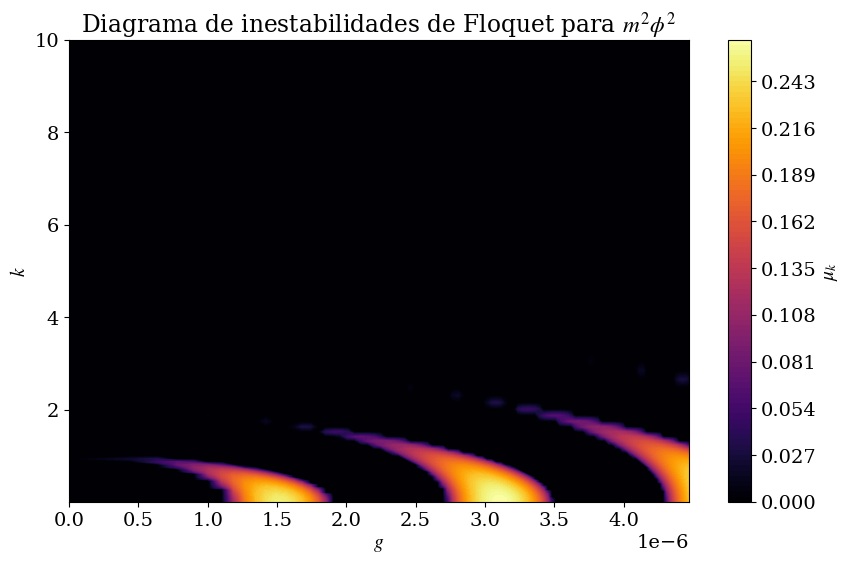

In [ ]:
# Calculemos una tabla de inestabilidades de Mathieu para ver si funciona el código

phi0 = 1e6
phi_dot0 = 0
y0 = (phi0, phi_dot0)
E = 0.5 * phi_dot0**2 + 0.5 * phi0**2

qs = np.linspace(0, 5, 100)
ks = np.logspace(-2, 1, 100)
gs = []

for q in qs:
    g = 2 * np.sqrt(q) / phi0
    gs.append(g)

G, K = np.meshgrid(gs, ks)
mu = np.zeros((len(ks), len(gs)), dtype=complex)

for i, g in enumerate(tqdm(gs)):
    Tosc = oscilation(E, phi0, g)
    for j, k in enumerate(ks):
        mu[j, i] = calculate_mu_k(k, g, y0, Tosc)


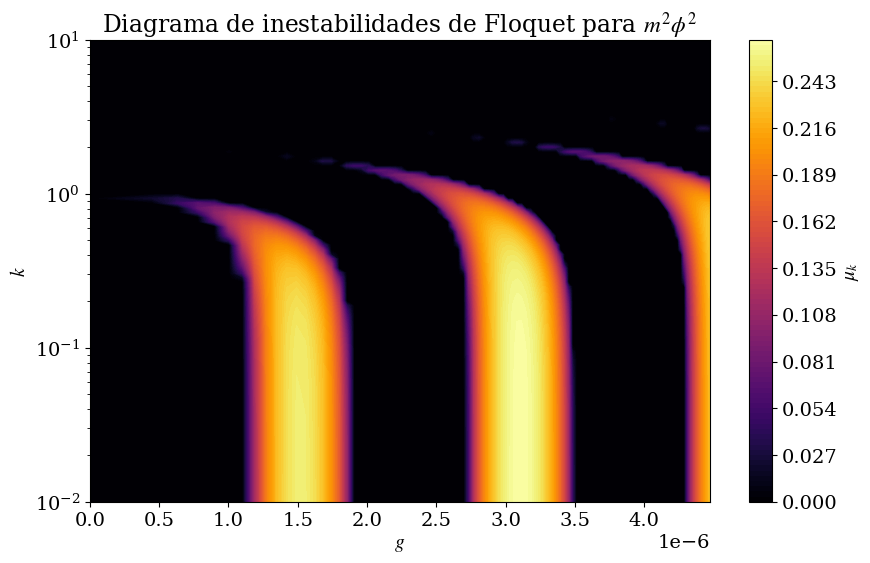

In [ ]:
# Ahora grafiquemos el diagrama de inestabilidades
plt.figure(figsize=(10, 6))
plt.contourf(gs, ks, np.real(mu), levels=100, cmap='inferno')
plt.colorbar(label=r'$\mu_k$')
plt.xlabel(r'$g$')
plt.ylabel(r'$k$')
plt.title(r'Diagrama de inestabilidades de Floquet para $m^2 \phi^2$')
plt.yscale('log')
plt.show()

## $\lambda \phi^4$

Consideraciones:
- La ecuación adimensional es 

$$\ddot{\tilde{\chi}}_k + \left( \tilde{k}^2 + q \tilde{\phi}^2 \right) \tilde{\chi}_k = 0$$

dónde $\displaystyle q = \frac{g^2}{\lambda}$.

In [35]:
# Función para armarse la matriz de monodromía y calcular los coeficientes de Floquet
def calculate_mu_k(k, q, y0, Tosc):
    phi0, phi_dot0 = y0

    def pert(t, y, k, q):
        phi, phi_dot, chi_k, chi_dot_k = y
        phi_ddot = - phi**3
        chi_ddot_k = - (k**2 + q * phi**2) * chi_k
        return [phi_dot, phi_ddot, chi_dot_k, chi_ddot_k]

    t_span = (0, Tosc)

    sol1 = solve_ivp(pert, t_span, [phi0, phi_dot0, 1.0, 0.0], t_eval=[Tosc], method='RK45', rtol=1e-6, args=(k, q))
    y_final1 = sol1.y[:, -1]

    sol2 = solve_ivp(pert, t_span, [phi0, phi_dot0, 0.0, 1.0], t_eval=[Tosc], method='RK45', rtol=1e-6, args=(k, q))
    y_final2 = sol2.y[:, -1]

    M = np.array([
        [y_final1[2], y_final2[2]],
        [y_final1[3], y_final2[3]]
    ])

    tr_M = np.trace(M)
    argument = np.abs(tr_M / 2.0)

    if argument > 1.0:
        mu = np.arccosh(argument) / Tosc
        return mu
    else:
        return 0.0
    
# Función para calcular el período de oscilación del inflatón
def oscilation(E):
    def integrand(phi):
        V = 0.25 * phi**4
        return 1.0 / np.sqrt(2 * (E - V))
    phimax = (4*E)**(1/4)
    integral, _ = quad(integrand, 0, phimax)
    Tosc = 4*integral
    return Tosc

In [36]:
# Calculemos una tabla de inestabilidades de Mathieu para ver si funciona el código

phi0 = 1
phi_dot0 = 0

y0 = (phi0, phi_dot0)
E = 0.5 * phi_dot0**2 + 0.25 * phi0**4

qs = np.linspace(0, 25, 100)
ks = np.linspace(0, 2, 100)

# Q, K = np.meshgrid(qs, ks)
mu = np.zeros((len(ks), len(qs)), dtype=complex)
Tosc = oscilation(E)

for i, q in enumerate(tqdm(qs)):
    for j, k in enumerate(ks):
        mu[j, i] = calculate_mu_k(k, q, y0, Tosc)

  0%|          | 0/100 [00:00<?, ?it/s]

100%|██████████| 100/100 [02:28<00:00,  1.49s/it]


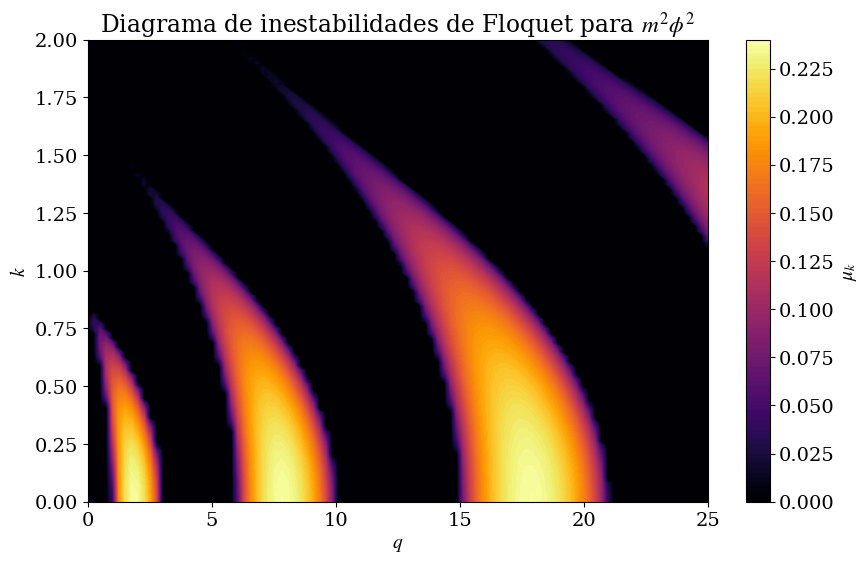

In [39]:
# Ahora grafiquemos el diagrama de inestabilidades
plt.figure(figsize=(10, 6))
plt.contourf(qs, ks, np.real(mu), levels=100, cmap='inferno')
plt.colorbar(label=r'$\mu_k$')
plt.xlabel(r'$q$')
plt.ylabel(r'$k$')
plt.title(r'Diagrama de inestabilidades de Floquet para $m^2 \phi^2$')
plt.show()